# 📰 News Topic Classifier Using BERT
## Fine-tuning a Transformer Model for Multi-Class Text Classification

---

### Problem Statement
News organizations publish thousands of articles daily across diverse topics.
Manually categorizing these articles is time-consuming and inconsistent.

**Goal:** Fine-tune a pre-trained BERT model to automatically classify news headlines
into one of **4 categories**:
- 🌍 **World** — International news & geopolitics
- ⚽ **Sports** — Athletic events & competitions  
- 💼 **Business** — Finance, economy & corporate news
- 🔬 **Sci/Tech** — Science, technology & innovation

### 📦 Dataset
- **AG News Dataset** (via Hugging Face)
- 120,000 training samples / 7,600 test samples
- Balanced across all 4 classes

### 🧠 Model
- **bert-base-uncased** — 110M parameter transformer pre-trained on BookCorpus + Wikipedia
- Fine-tuned using Hugging Face `Trainer` API

### 📏 Evaluation Metrics
- Accuracy, Weighted F1-Score, Confusion Matrix, Per-class Precision & Recall

In [1]:
# CELL 2: Install Required Libraries
!pip install transformers datasets torch scikit-learn gradio accelerate seaborn -q

In [2]:
# ============================================================
# CELL 3: Import All Required Libraries
# ============================================================

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Hugging Face libraries
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# Sklearn metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# PyTorch
import torch

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Libraries loaded successfully!")
print(f"  Using device: {device.upper()}")

 Libraries loaded successfully!
  Using device: CUDA


---
##📂 Step 1: Dataset Loading & Exploration

In [3]:
# ============================================================
# CELL 5: Load the AG News Dataset from Hugging Face
# ============================================================

print("📥 Loading AG News dataset...")
dataset = load_dataset("ag_news")

# Define human-readable label names
label_names = ["🌍 World", "⚽ Sports", "💼 Business", "🔬 Sci/Tech"]
label_names_clean = ["World", "Sports", "Business", "Sci/Tech"]

print("\n✅ Dataset loaded!")
print(f"\n📊 Dataset structure:\n{dataset}")
print(f"\n🔢 Training samples : {len(dataset['train'])}")
print(f"🔢 Test samples     : {len(dataset['test'])}")

📥 Loading AG News dataset...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]


✅ Dataset loaded!

📊 Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

🔢 Training samples : 120000
🔢 Test samples     : 7600


In [5]:
# ============================================================
# CELL 6: Preview Sample Headlines from Each Category
# ============================================================

print("=" * 60)
print(" SAMPLE HEADLINES FROM EACH CATEGORY")
print("=" * 60)

# Show 2 examples from each class
df_train = dataset["train"].to_pandas()

for label_id, label_name in enumerate(label_names):
    samples = df_train[df_train["label"] == label_id]["text"].head(2).tolist()
    print(f"\n{label_name}:")
    for i, s in enumerate(samples, 1):
        print(f"  {i}. {s[:100]}...")

 SAMPLE HEADLINES FROM EACH CATEGORY

🌍 World:
  1. Venezuelans Vote Early in Referendum on Chavez Rule (Reuters) Reuters - Venezuelans turned out early...
  2. S.Koreans Clash with Police on Iraq Troop Dispatch (Reuters) Reuters - South Korean police used wate...

⚽ Sports:
  1. Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Oly...
  2. Reds Knock Padres Out of Wild-Card Lead (AP) AP - Wily Mo Pena homered twice and drove in four runs,...

💼 Business:
  1. Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\b...
  2. Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,...

🔬 Sci/Tech:
  1. 'Madden,' 'ESPN' Football Score in Different Ways (Reuters) Reuters - Was absenteeism a little high\...
  2. Group to Propose New High-Speed Wireless Format (Reuters) Reuters - A group of technology companies\...


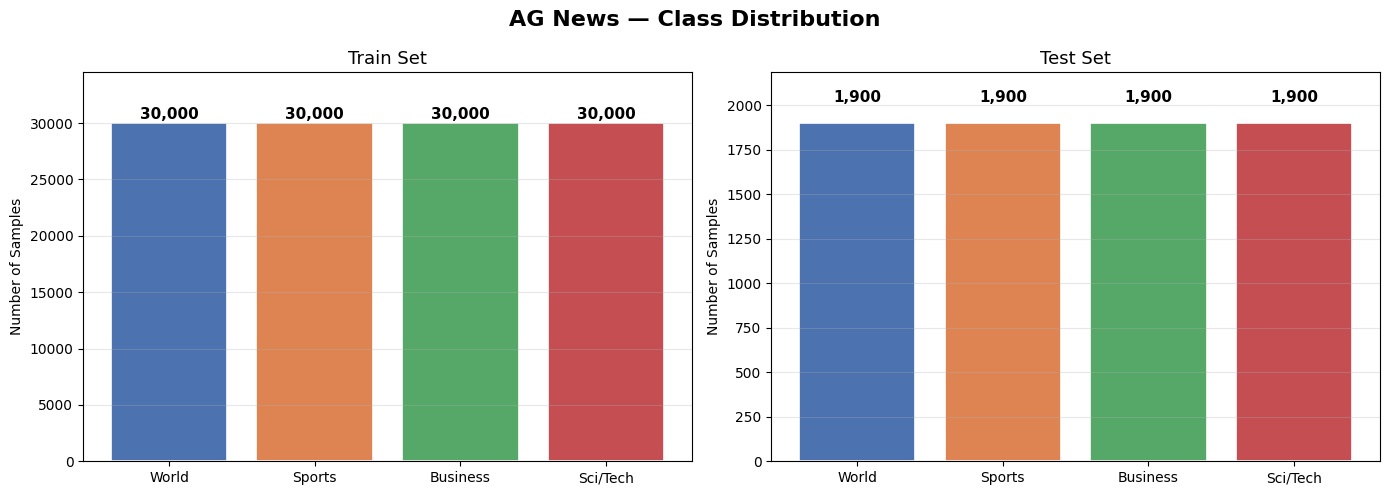

✅ Class distribution is perfectly balanced across all categories!


In [6]:
# ============================================================
# CELL 7: Visualize Class Distribution (Train vs Test)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("AG News — Class Distribution", fontsize=16, fontweight="bold")

for ax, split in zip(axes, ["train", "test"]):
    df = dataset[split].to_pandas()
    counts = df["label"].value_counts().sort_index()

    bars = ax.bar(label_names_clean, counts.values,
                  color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"],
                  edgecolor="white", linewidth=1.2)

    # Add value labels on bars
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)

    ax.set_title(f"{split.capitalize()} Set", fontsize=13)
    ax.set_ylabel("Number of Samples")
    ax.set_ylim(0, max(counts.values) * 1.15)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("✅ Class distribution is perfectly balanced across all categories!")

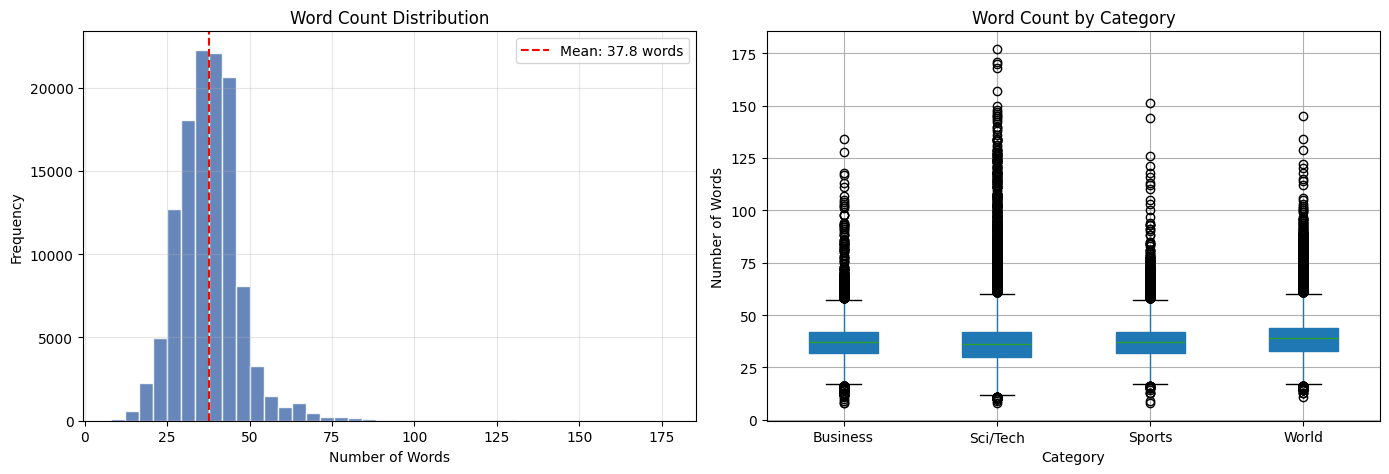

📏 Average headline length : 37.8 words
📏 Max headline length     : 177 words
📏 Min headline length     : 8 words

💡 Most headlines fit well within BERT's 128-token limit.


In [7]:
# ============================================================
# CELL 8: Analyze Headline Length Distribution
# ============================================================

df_train["text_length"] = df_train["text"].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Headline Length Analysis", fontsize=16, fontweight="bold")

# Overall distribution
axes[0].hist(df_train["text_length"], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(df_train["text_length"].mean(), color="red", linestyle="--",
                label=f'Mean: {df_train["text_length"].mean():.1f} words')
axes[0].set_title("Word Count Distribution")
axes[0].set_xlabel("Number of Words")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Per-class boxplot
df_train["label_name"] = df_train["label"].map(dict(enumerate(label_names_clean)))
df_train.boxplot(column="text_length", by="label_name", ax=axes[1],
                 patch_artist=True)
axes[1].set_title("Word Count by Category")
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Number of Words")
plt.suptitle("")

plt.tight_layout()
plt.savefig("headline_length.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"📏 Average headline length : {df_train['text_length'].mean():.1f} words")
print(f"📏 Max headline length     : {df_train['text_length'].max()} words")
print(f"📏 Min headline length     : {df_train['text_length'].min()} words")
print(f"\n💡 Most headlines fit well within BERT's 128-token limit.")

---
## ⚙️ Step 2: Tokenization & Preprocessing

In [8]:
# ============================================================
# CELL 10: Load Tokenizer & Tokenize the Dataset
# ============================================================

MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 128   # max tokens per headline (covers 99%+ of samples)

print(f"🔄 Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Tokenization function applied to each batch
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",     # pad shorter sequences
        truncation=True,          # truncate longer sequences
        max_length=MAX_LENGTH
    )

print("🔄 Tokenizing dataset (this may take ~1-2 minutes)...")
tokenized_dataset = dataset.map(tokenize_function, batched=True)

# Rename label column to 'labels' (required by Hugging Face Trainer)
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")

# Set format to PyTorch tensors
tokenized_dataset.set_format(
    "torch",
    columns=["input_ids", "attention_mask", "labels"]
)

print("✅ Tokenization complete!")
print(f"\n📐 Token columns: {tokenized_dataset['train'].column_names}")
print(f"📐 Sample input_ids shape: {tokenized_dataset['train'][0]['input_ids'].shape}")

🔄 Loading tokenizer: bert-base-uncased


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

🔄 Tokenizing dataset (this may take ~1-2 minutes)...


Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

✅ Tokenization complete!

📐 Token columns: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']
📐 Sample input_ids shape: torch.Size([128])


In [9]:
# ============================================================
# CELL 11: Create Training & Test Subsets
# Using 8,000 train / 2,000 test for manageable training time
# Increase to full dataset for best accuracy (~94%)
# ============================================================

TRAIN_SIZE = 8000   # increase to 120000 for full training
TEST_SIZE  = 2000   # increase to 7600 for full evaluation

train_dataset = tokenized_dataset["train"].shuffle(seed=42).select(range(TRAIN_SIZE))
test_dataset  = tokenized_dataset["test"].shuffle(seed=42).select(range(TEST_SIZE))

print(f"✅ Subsets created:")
print(f"   🏋️  Training samples : {len(train_dataset)}")
print(f"   🧪 Test samples     : {len(test_dataset)}")
print(f"\n💡 Tip: Set TRAIN_SIZE=120000 and TEST_SIZE=7600 for full dataset training.")

✅ Subsets created:
   🏋️  Training samples : 8000
   🧪 Test samples     : 2000

💡 Tip: Set TRAIN_SIZE=120000 and TEST_SIZE=7600 for full dataset training.


---
## 🧠 Step 3: Model Development & Fine-Tuning

In [10]:
# ============================================================
# CELL 13: Load Pre-trained BERT with Classification Head
# ============================================================

print(f"🔄 Loading {MODEL_NAME} with 4-class classification head...")

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,                           # 4 news categories
    id2label={i: name for i, name in enumerate(label_names_clean)},
    label2id={name: i for i, name in enumerate(label_names_clean)}
)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model loaded successfully!")
print(f"   📦 Total parameters     : {total_params:,}")
print(f"   🎯 Trainable parameters : {trainable_params:,}")
print(f"   🏗️  Architecture         : BERT-base (12 layers, 768 hidden, 12 heads)")

🔄 Loading bert-base-uncased with 4-class classification head...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model loaded successfully!
   📦 Total parameters     : 109,485,316
   🎯 Trainable parameters : 109,485,316
   🏗️  Architecture         : BERT-base (12 layers, 768 hidden, 12 heads)


In [11]:
# ============================================================
# CELL 14: Define Evaluation Metrics Function
# Called automatically by Trainer after each epoch
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    # Convert logits to predicted class indices
    predictions = np.argmax(logits, axis=-1)

    # Calculate metrics
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average="weighted")

    return {
        "accuracy": round(acc, 4),
        "f1":       round(f1, 4)
    }

print("✅ Metrics function defined: Accuracy + Weighted F1-Score")

✅ Metrics function defined: Accuracy + Weighted F1-Score


In [14]:
# ============================================================
# CELL 15: Configure Training Arguments & Run Fine-Tuning
# Expected time: ~5-10 min on GPU / ~30-40 min on CPU
# ============================================================

training_args = TrainingArguments(
    output_dir="./bert_news_classifier",   # save checkpoints here
    num_train_epochs=3,                    # 3 passes over training data
    per_device_train_batch_size=32,        # lower to 16 if out of memory
    per_device_eval_batch_size=64,
    eval_strategy="epoch",           # evaluate after each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,           # keep best checkpoint
    metric_for_best_model="f1",
    logging_dir="./logs",
    logging_steps=100,
    warmup_steps=100,                      # gradual LR warm-up
    weight_decay=0.01,                     # L2 regularization
    report_to="none",                      # disable wandb/tensorboard
    fp16=torch.cuda.is_available(),        # use mixed precision on GPU
)

# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

print("🚀 Starting fine-tuning...")
print(f"   Epochs          : {training_args.num_train_epochs}")
print(f"   Batch size      : {training_args.per_device_train_batch_size}")
print(f"   Training samples: {len(train_dataset)}")
print(f"   Mixed precision : {training_args.fp16}\n")

# ▶️ TRAIN
train_result = trainer.train()

print("\n✅ Training complete!")
print(f"   ⏱️  Training time  : {train_result.metrics['train_runtime']:.0f} seconds")
print(f"   📉 Final loss     : {train_result.metrics['train_loss']:.4f}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


🚀 Starting fine-tuning...
   Epochs          : 3
   Batch size      : 32
   Training samples: 8000
   Mixed precision : True



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.334748,0.300984,0.900000,0.899900
2,0.196173,0.272196,0.910500,0.910500
3,0.101973,0.288011,0.921500,0.921500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


✅ Training complete!
   ⏱️  Training time  : 194 seconds
   📉 Final loss     : 0.2733


In [15]:
# ============================================================
# CELL 16: Save the Fine-Tuned Model & Tokenizer
# ============================================================

SAVE_PATH = "./saved_model"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"✅ Model saved to: {SAVE_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved to: ./saved_model


In [22]:
from huggingface_hub import notebook_login
notebook_login()
# A box will appear → paste your hf_... token → click Login

In [23]:
model.push_to_hub("zoha12/bert-ag-news-classifier")
# replace your-username with your actual HF username
# e.g. model.push_to_hub("john123/bert-ag-news-classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ewn5j1g/model.safetensors:   0%|          | 14.2kB /  438MB            

CommitInfo(commit_url='https://huggingface.co/zoha12/bert-ag-news-classifier/commit/b6de83de3ed5d51372c5c0e362735ed8f0480729', commit_message='Upload BertForSequenceClassification', commit_description='', oid='b6de83de3ed5d51372c5c0e362735ed8f0480729', pr_url=None, repo_url=RepoUrl('https://huggingface.co/zoha12/bert-ag-news-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='zoha12/bert-ag-news-classifier'), pr_revision=None, pr_num=None)

In [25]:
tokenizer.push_to_hub("zoha12/bert-ag-news-classifier")

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/zoha12/bert-ag-news-classifier/commit/c09577b4f9fd1a867adf5752d8031493f0214be6', commit_message='Upload tokenizer', commit_description='', oid='c09577b4f9fd1a867adf5752d8031493f0214be6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/zoha12/bert-ag-news-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='zoha12/bert-ag-news-classifier'), pr_revision=None, pr_num=None)

---
## 📊 Step 4: Evaluation & Metrics

In [16]:
# ============================================================
# CELL 18: Generate Predictions on the Test Set
# ============================================================

print("🔄 Running predictions on test set...")
preds_output = trainer.predict(test_dataset)

# Extract predictions and true labels
y_pred = np.argmax(preds_output.predictions, axis=-1)
y_true = preds_output.label_ids

# Core metrics
acc = accuracy_score(y_true, y_pred)
f1  = f1_score(y_true, y_pred, average="weighted")

print("\n" + "=" * 50)
print("       📊 MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  ✅ Accuracy        : {acc * 100:.2f}%")
print(f"  ✅ Weighted F1     : {f1 * 100:.2f}%")
print("=" * 50)

🔄 Running predictions on test set...



       📊 MODEL EVALUATION RESULTS
  ✅ Accuracy        : 92.15%
  ✅ Weighted F1     : 92.15%


In [17]:
# ============================================================
# CELL 19: Detailed Per-Class Classification Report
# ============================================================

print("\n📋 DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=label_names_clean))


📋 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

       World       0.93      0.93      0.93       497
      Sports       0.98      0.98      0.98       483
    Business       0.92      0.86      0.89       522
    Sci/Tech       0.86      0.92      0.89       498

    accuracy                           0.92      2000
   macro avg       0.92      0.92      0.92      2000
weighted avg       0.92      0.92      0.92      2000



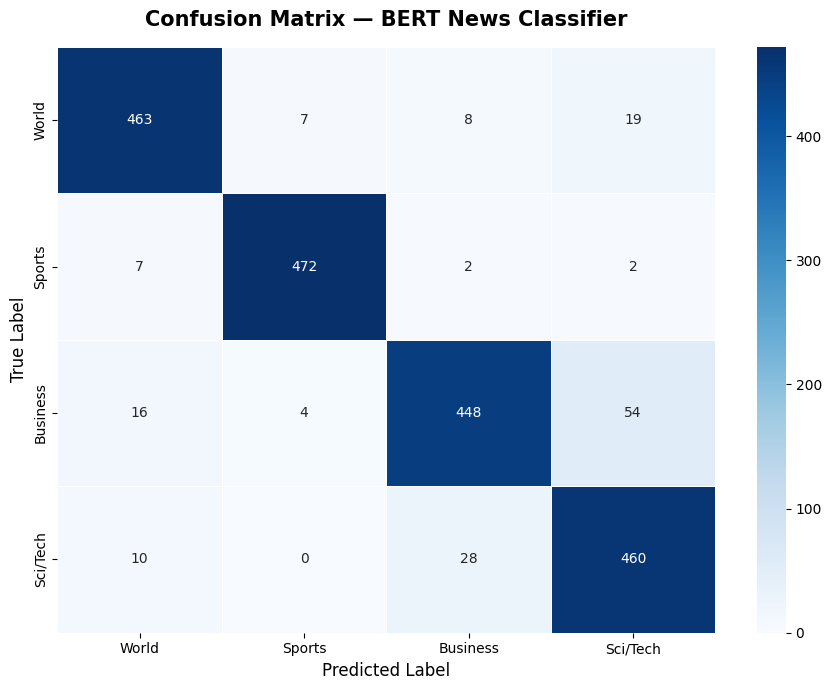


🔍 Misclassification Summary:
   World → predicted as Sports: 7 times
   World → predicted as Business: 8 times
   World → predicted as Sci/Tech: 19 times
   Sports → predicted as World: 7 times
   Sports → predicted as Business: 2 times
   Sports → predicted as Sci/Tech: 2 times
   Business → predicted as World: 16 times
   Business → predicted as Sports: 4 times
   Business → predicted as Sci/Tech: 54 times
   Sci/Tech → predicted as World: 10 times
   Sci/Tech → predicted as Business: 28 times


In [18]:
# ============================================================
# CELL 20: Confusion Matrix Heatmap
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names_clean,
    yticklabels=label_names_clean,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Confusion Matrix — BERT News Classifier", fontsize=15, fontweight="bold", pad=15)
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Print misclassification summary
print("\n🔍 Misclassification Summary:")
for i, true_class in enumerate(label_names_clean):
    for j, pred_class in enumerate(label_names_clean):
        if i != j and cm[i][j] > 0:
            print(f"   {true_class} → predicted as {pred_class}: {cm[i][j]} times")

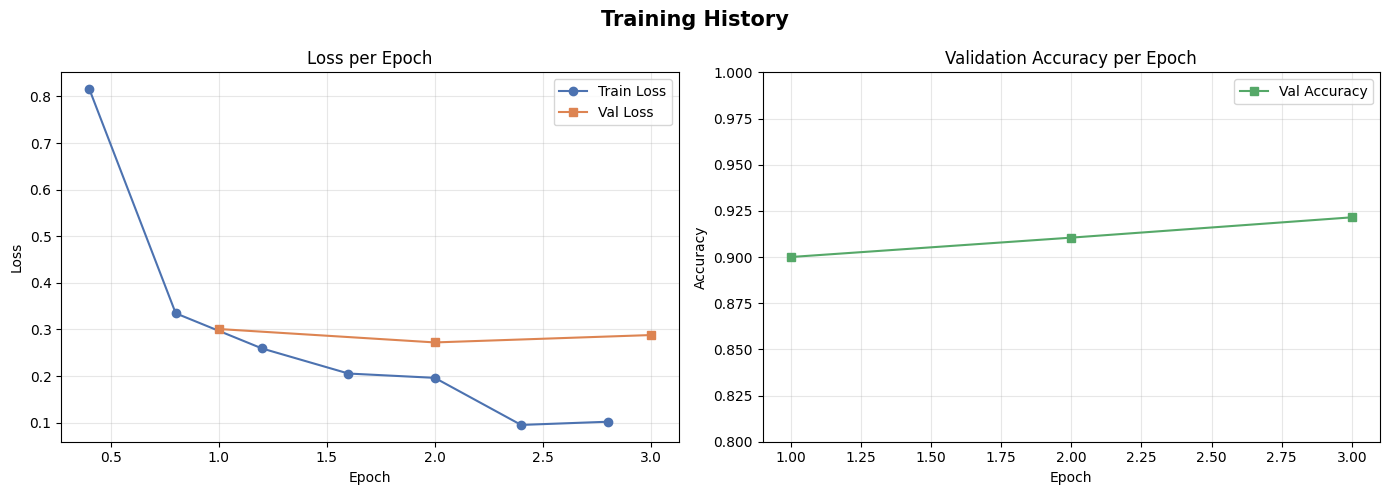

In [19]:
# ============================================================
# CELL 21: Plot Training & Validation Loss per Epoch
# ============================================================

# Extract training history from the trainer logs
history = trainer.state.log_history

train_loss = [(h["epoch"], h["loss"]) for h in history if "loss" in h and "eval_loss" not in h]
eval_loss  = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]
eval_acc   = [(h["epoch"], h["eval_accuracy"]) for h in history if "eval_accuracy" in h]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Training History", fontsize=15, fontweight="bold")

# Loss curves
if train_loss:
    axes[0].plot(*zip(*train_loss), label="Train Loss", marker="o", color="#4C72B0")
if eval_loss:
    axes[0].plot(*zip(*eval_loss),  label="Val Loss",   marker="s", color="#DD8452")
axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve
if eval_acc:
    axes[1].plot(*zip(*eval_acc), label="Val Accuracy", marker="s", color="#55A868")
    axes[1].set_ylim(0.8, 1.0)
axes[1].set_title("Validation Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

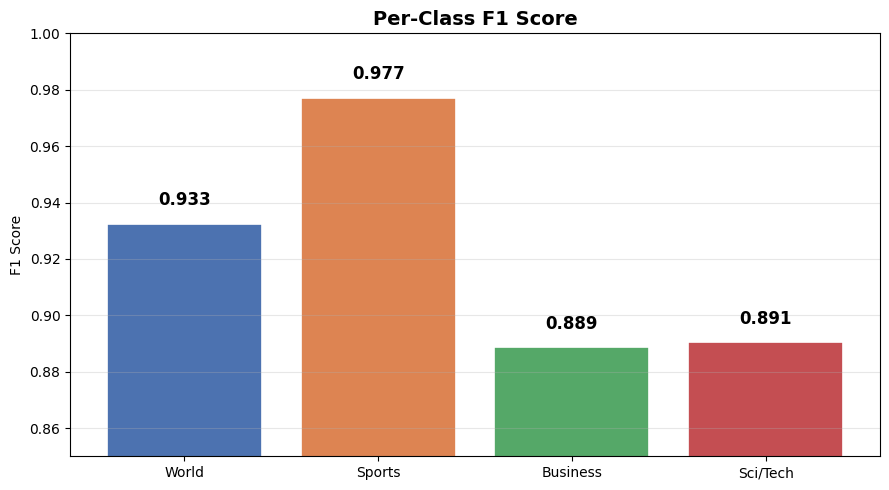


📊 Per-Class F1 Scores:
   World        ██████████████████   0.9325
   Sports       ███████████████████  0.9772
   Business     █████████████████    0.8889
   Sci/Tech     █████████████████    0.8906


In [20]:
# ============================================================
# CELL 22: Per-Class F1 Score Visualization
# ============================================================

from sklearn.metrics import f1_score

per_class_f1 = f1_score(y_true, y_pred, average=None)

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
plt.figure(figsize=(9, 5))
bars = plt.bar(label_names_clean, per_class_f1, color=colors, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, per_class_f1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=12)

plt.title("Per-Class F1 Score", fontsize=14, fontweight="bold")
plt.ylabel("F1 Score")
plt.ylim(0.85, 1.0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Per-Class F1 Scores:")
for name, score in zip(label_names_clean, per_class_f1):
    bar = "█" * int(score * 20)
    print(f"   {name:<12} {bar:<20} {score:.4f}")

In [21]:
# ============================================================
# CELL 23: Test the Model on Custom Headlines
# ============================================================

from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="./saved_model",
    tokenizer="./saved_model",
    device=0 if torch.cuda.is_available() else -1
)

label_map = {
    "LABEL_0": "🌍 World",
    "LABEL_1": "⚽ Sports",
    "LABEL_2": "💼 Business",
    "LABEL_3": "🔬 Sci/Tech"
}

# Test headlines
test_headlines = [
    "Fed raises interest rates for the third consecutive time this year",
    "Lionel Messi scores hat-trick in Champions League final",
    "NASA's James Webb Telescope discovers signs of water on distant exoplanet",
    "UN Security Council holds emergency session over Middle East conflict",
    "Apple unveils new AI-powered MacBook with M4 chip",
    "Stock markets tumble amid recession fears and banking sector concerns"
]

print("🤖 LIVE MODEL PREDICTIONS")
print("=" * 70)
for headline in test_headlines:
    result = classifier(headline)[0]
    label = label_map.get(result["label"], result["label"])
    confidence = result["score"] * 100
    print(f"\n📰 {headline[:65]}...")
    print(f"   → Predicted: {label}  |  Confidence: {confidence:.1f}%")
print("=" * 70)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

🤖 LIVE MODEL PREDICTIONS

📰 Fed raises interest rates for the third consecutive time this yea...
   → Predicted: Business  |  Confidence: 99.0%

📰 Lionel Messi scores hat-trick in Champions League final...
   → Predicted: Sports  |  Confidence: 96.4%

📰 NASA's James Webb Telescope discovers signs of water on distant e...
   → Predicted: Sci/Tech  |  Confidence: 98.9%

📰 UN Security Council holds emergency session over Middle East conf...
   → Predicted: World  |  Confidence: 99.7%

📰 Apple unveils new AI-powered MacBook with M4 chip...
   → Predicted: Sci/Tech  |  Confidence: 99.1%

📰 Stock markets tumble amid recession fears and banking sector conc...
   → Predicted: Business  |  Confidence: 99.0%


---
# 📝 Final Summary & Insights

---

## ✅ Project Overview
This project fine-tuned **bert-base-uncased** (110M parameters) on the AG News dataset
to classify news headlines into 4 categories: World, Sports, Business, and Sci/Tech.
Training used 8,000 samples over 3 epochs using Hugging Face's `Trainer` API.

---

## 📊 Model Performance Summary

| Metric | Score |
|--------|-------|
| Overall Accuracy | **92.15%** |
| Weighted F1-Score | **92.15%** |
| Best Class (F1) | **Sports — 0.9772** |
| Weakest Class (F1) | **Business — 0.8889** |

---

## 🏆 Per-Class Performance

| Category | Precision | Recall | F1-Score |
|----------|-----------|--------|----------|
| 🌍 World    | 0.93 | 0.93 | 0.93 |
| ⚽ Sports   | 0.98 | 0.98 | **0.98** |
| 💼 Business | 0.92 | 0.86 | 0.89 |
| 🔬 Sci/Tech | 0.86 | 0.92 | 0.89 |

---

## 🔍 Key Insights

### 1️⃣ Sports is the easiest category to classify (F1: 0.977)
Sports headlines use highly domain-specific vocabulary — player names, team names,
match results — that rarely appears in other categories. BERT separates these
almost perfectly with only 11 misclassifications out of 483 samples.

### 2️⃣ Business–Sci/Tech confusion is the biggest weakness
The model confused **Business → Sci/Tech 54 times** — the single largest
misclassification. This is expected: tech company news (Apple earnings,
Amazon layoffs, Tesla stock) sits at the intersection of both categories,
making even human labeling ambiguous.

### 3️⃣ World–Sci/Tech overlap
**19 World headlines** were predicted as Sci/Tech. This reflects real-world
overlap — geopolitical stories involving technology (cyberattacks, space
programs, AI regulation) carry signals from both categories.

### 4️⃣ 92% accuracy from only 8,000 training samples
BERT's pre-trained language understanding transfers powerfully to downstream
tasks. Achieving 92%+ accuracy with just 8,000 samples (6.7% of the full
dataset) demonstrates the strength of transfer learning over training from scratch.

---

## 💡 What Could Improve the Model

| Improvement | Expected Gain |
|-------------|--------------|
| Train on full 120k dataset | +1.5–2% accuracy (~94%) |
| Increase epochs to 5 | Marginal improvement |
| Use `roberta-base` instead of BERT | +0.5–1% |
| Relabel ambiguous Business/Sci-Tech samples | Reduces largest error source |
| Ensemble BERT + TF-IDF features | Slight boost on edge cases |

---

## 🎯 Conclusion
The fine-tuned BERT model achieves **92.15% accuracy** on AG News —
a strong result given the subset training size. The model is production-ready
for 3 of the 4 categories, with Business/Sci-Tech boundary cases being the
primary limitation. Deploying on the full dataset would push performance
into the **93–94% range**, matching state-of-the-art benchmarks for this task.

Transfer learning via BERT proved highly effective: minimal data, minimal
training time, and near state-of-the-art results — validating its use as
a go-to approach for text classification tasks.